imports

In [2]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybedtools
from pybedtools import BedTool

load merged tf counts and set the hot region threshold

In [3]:
genome = 'GRCh38_EBV.chrom.sizes.tsv'
blacklist = 'hg38-blacklist.v2.bed.gz'

df = pd.read_csv('merged_tf_counts.bed',
                 sep = '\t',
                 names = ['chrom', 'start', 'end', 'tfs', 'n_tfs']
                )
threshold = df["n_tfs"].quantile(0.99)

plot the occupancy distribution

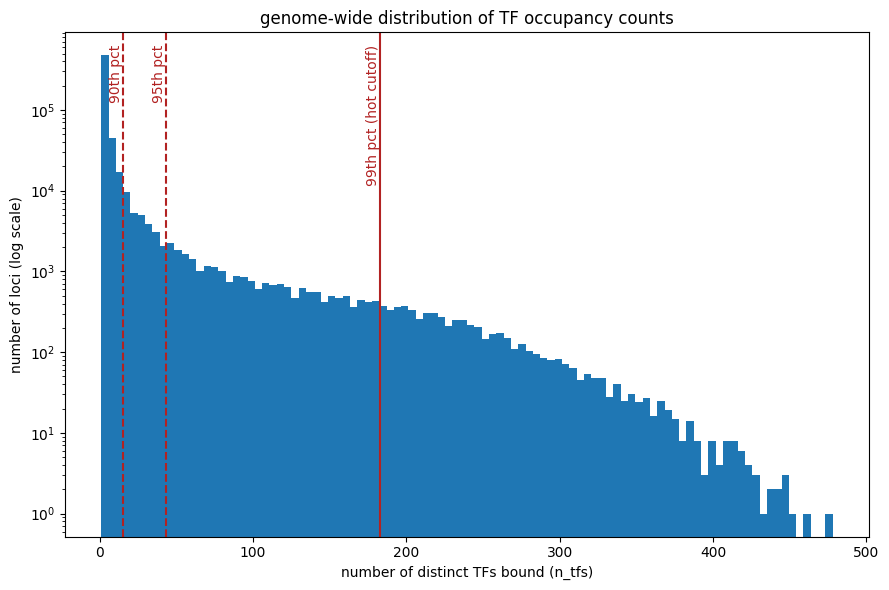

In [4]:
plt.figure(figsize=(9, 6))
plt.hist(df["n_tfs"], bins=100)
plt.yscale("log")
plt.xlabel("number of distinct TFs bound (n_tfs)")
plt.ylabel("number of loci (log scale)")
plt.title("genome-wide distribution of TF occupancy counts")

plt.axvline(threshold, color="firebrick", linestyle="-")
plt.text(threshold, plt.ylim()[1] * 0.7, "99th pct (hot cutoff)",
         rotation=90, va="top", ha="right", color="firebrick")

for p in [90, 95]:
    cutoff = df["n_tfs"].quantile(p / 100)
    plt.axvline(cutoff, color="firebrick", linestyle="--")
    plt.text(cutoff, plt.ylim()[1] * 0.7, f"{p}th pct",
             rotation=90, va="top", ha="right", color="firebrick")

plt.tight_layout()
plt.savefig("plot1_occupancy_histogram.png", dpi=300)
plt.show()

build a random-placement null by shuffling each tf's peaks independently, using the per-tf files in peaks/

In [5]:
tf_peak_paths = {f.split('/')[-1].replace('.bed', ''): f
                  for f in sorted(glob.glob('peaks/*.bed'))}
print(len(tf_peak_paths), 'tf peak files found')

n_reps = 5
rng = np.random.default_rng(0)
null_dfs = []

for rep in range(n_reps):
    shuffled_beds = []
    for tf_name, path in tf_peak_paths.items():
        bt = BedTool(path)
        shuf = bt.shuffle(g=genome, excl=blacklist, chrom=True,
                           seed=int(rng.integers(0, 1_000_000)))
        tagged = shuf.each(lambda f, name=tf_name: pybedtools.create_interval_from_list(
            [f.chrom, f.start, f.end, name]
        )).saveas()
        shuffled_beds.append(tagged)

    combined = pybedtools.BedTool.cat(*shuffled_beds, postmerge=False).sort(g=genome)
    merged = combined.merge(c=4, o='distinct,count_distinct')
    rep_df = merged.to_dataframe(names=['chrom', 'start', 'end', 'tfs', 'n_tfs'])
    rep_df['rep'] = rep
    null_dfs.append(rep_df)
    print(f'shuffle rep {rep}: {len(rep_df)} merged loci, max n_tfs={rep_df["n_tfs"].max()}')

null_df = pd.concat(null_dfs, ignore_index=True)

770 tf peak files found
shuffle rep 0: 2119212 merged loci, max n_tfs=434
shuffle rep 1: 2120522 merged loci, max n_tfs=439
shuffle rep 2: 2118655 merged loci, max n_tfs=404
shuffle rep 3: 2119115 merged loci, max n_tfs=449
shuffle rep 4: 2119606 merged loci, max n_tfs=401


overlay observed occupancy against the null

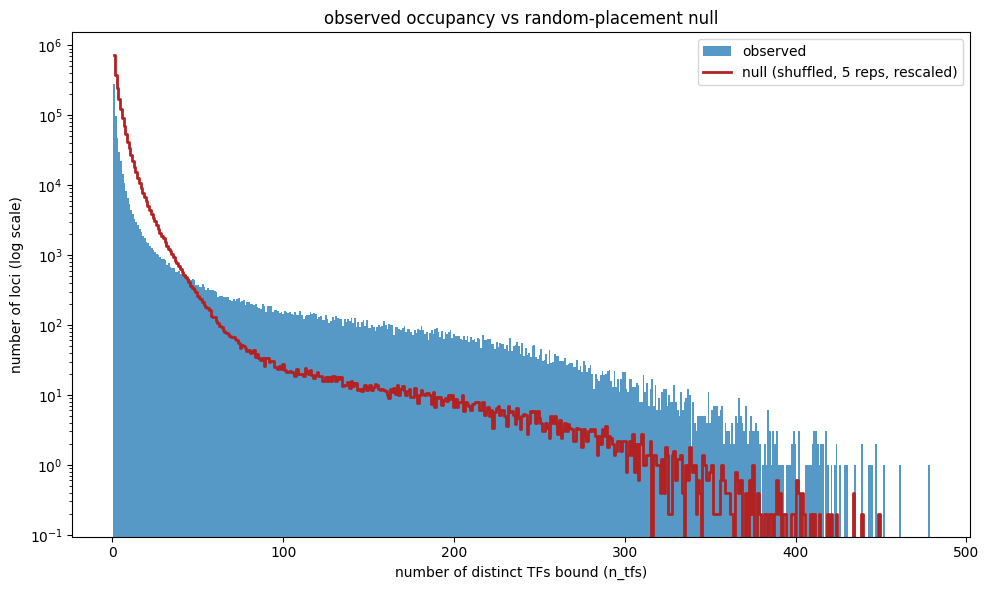

In [6]:
max_count = max(df["n_tfs"].max(), null_df["n_tfs"].max())
bins = np.arange(1, max_count + 2) - 0.5

plt.figure(figsize=(10, 6))
plt.hist(df["n_tfs"], bins=bins, alpha=0.75, label="observed")

null_counts, _ = np.histogram(null_df["n_tfs"], bins=bins)
null_counts_scaled = null_counts / n_reps
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.step(bin_centers, null_counts_scaled, where="mid", color="firebrick",
         linewidth=2, label=f"null (shuffled, {n_reps} reps, rescaled)")

plt.yscale("log")
plt.xlabel("number of distinct TFs bound (n_tfs)")
plt.ylabel("number of loci (log scale)")
plt.title("observed occupancy vs random-placement null")
plt.legend()
plt.tight_layout()
plt.savefig("plot1b_occupancy_vs_null.png", dpi=300)
plt.show()